In [2]:
!pip install rdkit chembl_webresource_client -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.1 MB/s eta 0:00:00


In [3]:
from chembl_webresource_client.new_client import new_client
import pandas as pd

# FABP5 target
target_id = "CHEMBL3674"

activity = new_client.activity

res = activity.filter(
    target_chembl_id=target_id,
    standard_type="IC50"
)

df = pd.DataFrame(res)

print("Records:", len(df))

df.head()



Records: 410


,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,1444785,[],CHEMBL833475,In vitro inhibitory concentration against epit...,B,None,None,BAO_0000190,...,Homo sapiens,Fatty acid-binding protein 5,9606,None,None,IC50,uM,UO_0000065,None,1.2
1,None,None,1444790,[],CHEMBL833475,In vitro inhibitory concentration against epit...,B,None,None,BAO_0000190,...,Homo sapiens,Fatty acid-binding protein 5,9606,None,None,IC50,uM,UO_0000065,None,30.0
2,None,None,1444793,[],CHEMBL833475,In vitro inhibitory concentration against epit...,B,None,None,BAO_0000190,...,Homo sapiens,Fatty acid-binding protein 5,9606,None,None,IC50,uM,UO_0000065,None,6.7
3,None,None,1444796,[],CHEMBL833475,In vitro inhibitory concentration against epit...,B,None,None,BAO_0000190,...,Homo sapiens,Fatty acid-binding protein 5,9606,None,None,IC50,uM,UO_0000065,None,3.0
4,None,None,1445061,[],CHEMBL833475,In vitro inhibitory concentration against epit...,B,None,None,BAO_0000190,...,Homo sapiens,Fatty acid-binding protein 5,9606,None,None,IC50,uM,UO_0000065,None,9.1


In [4]:
cols = [
    "molecule_chembl_id",
    "canonical_smiles",
    "standard_value",
    "standard_units"
]

df = df[cols]

df.head()

,molecule_chembl_id,canonical_smiles,standard_value,standard_units
0,CHEMBL82293,CCCCCCCCCCCCCCCC(=O)O,1200.0,nM
1,CHEMBL184817,O=C(O)CCn1c2ccccc2c2ccccc21,30000.0,nM
2,CHEMBL185595,O=C(O)CCCn1c2ccccc2c2ccccc21,6700.0,nM
3,CHEMBL184795,O=C(O)CCCCn1c2ccccc2c2ccccc21,3000.0,nM
4,CHEMBL363032,O=C(O)c1sccc1S(=O)(=O)n1c2ccccc2c2ccccc21,9100.0,nM


In [5]:
df = df.dropna()

df["standard_value"] = pd.to_numeric(
    df["standard_value"],
    errors="coerce"
)

df = df.dropna()

print("Clean records:", len(df))

Clean records: 403


In [8]:
df_active = df[df['standard_value'] < 1000]
print("Active records (IC50 < 1000 nM):")
display(df_active.head())
print(f"Total active records: {len(df_active)}")

Active records (IC50 < 1000 nM):


,molecule_chembl_id,canonical_smiles,standard_value,standard_units
27,CHEMBL3975095,Cc1noc(-c2c(NC(=O)C3=C(C(=O)O)CCC3)sc(C)c2C2CC...,120.0,nM
28,CHEMBL3913234,Cc1sc(NC(=O)C2=C(C(=O)O)C3CCC2CC3)c(-c2nc(C(F)...,60.0,nM
29,CHEMBL3979971,Cc1sc(NC(=O)C2=C(C(=O)O)CCCC2)c(-c2nc(C3CC3)no...,90.0,nM
30,CHEMBL3918729,Cc1c(C2CC2)sc(NC(=O)C2=C(C(=O)O)CCC2)c1-c1nc(C...,30.0,nM
31,CHEMBL3890665,Cc1c(C2CC2)sc(NC(=O)C2=C(C(=O)O)C3CCC2CC3)c1-c...,50.0,nM


Total active records: 231


In [9]:
df["active"] = (
    df["standard_value"] < 1000
).astype(int)

df["active"].value_counts()

,count
active,
1,231
0,172


In [13]:
pass

In [15]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

def smiles_to_fp(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    # Reverting to AllChem.GetMorganFingerprintAsBitVect as GetMorganFingerprintGenerator caused an ImportError
    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=2,
        nBits=1024
    )

    return np.array(fp)

fps = []

for s in df["canonical_smiles"]:
    fps.append(smiles_to_fp(s))

df["fp"] = fps

df = df[df["fp"].notnull()]

[05:16:30] DEPRECATION WARNING: please use MorganGenerator
[05:16:30] DEPRECATION WARNING: please use MorganGenerator
[05:16:30] DEPRECATION WARNING: please use MorganGenerator
[05:16:30] DEPRECATION WARNING: please use MorganGenerator
[05:16:30] DEPRECATION WARNING: please use MorganGenerator
[05:16:30] DEPRECATION WARNING: please use MorganGenerator
[05:16:30] DEPRECATION WARNING: please use MorganGenerator
[05:16:30] DEPRECATION WARNING: please use MorganGenerator
[05:16:30] DEPRECATION WARNING: please use MorganGenerator
[05:16:30] DEPRECATION WARNING: please use MorganGenerator
[05:16:30] DEPRECATION WARNING: please use MorganGenerator
[05:16:30] DEPRECATION WARNING: please use MorganGenerator
[05:16:30] DEPRECATION WARNING: please use MorganGenerator
[05:16:30] DEPRECATION WARNING: please use MorganGenerator
[05:16:30] DEPRECATION WARNING: please use MorganGenerator
[05:16:30] DEPRECATION WARNING: please use MorganGenerator
[05:16:30] DEPRECATION WARNING: please use MorganGenerat

In [17]:
X = np.stack(df["fp"])

y = df["active"]

print(X.shape)
print(y.shape)

(403, 1024)
(403,)


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [19]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

pred = model.predict(X_test)

prob = model.predict_proba(X_test)[:,1]

print(
    "Accuracy:",
    accuracy_score(y_test,pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test,prob)
)

Accuracy: 0.8518518518518519
ROC-AUC: 0.9376543209876543


In [20]:
print(X.shape)
print(y.value_counts())

(403, 1024)
active
1    231
0    172
Name: count, dtype: int64


In [21]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print(scores)
print("Mean ROC-AUC:", scores.mean())

[0.95248447 0.96552795 0.90550688 0.61700767 0.62915601]
Mean ROC-AUC: 0.8139365977658407


In [22]:
# Save dataframe to Excel

df.to_excel("FABP5_dataset.xlsx", index=False)

print("Excel file saved successfully!")

Excel file saved successfully!


In [23]:
from google.colab import files

files.download("FABP5_dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
cols = [
    "molecule_chembl_id",
    "canonical_smiles",
    "standard_value",
    "active"
]

df[cols].to_excel(
    "FABP5_clean_dataset.xlsx",
    index=False
)

from google.colab import files
files.download("FABP5_clean_dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print(scores)
print("Mean ROC-AUC:", scores.mean())

[0.95248447 0.96552795 0.90550688 0.61700767 0.62915601]
Mean ROC-AUC: 0.8139365977658407


In [27]:
import pandas as pd

importance = model.feature_importances_

imp_df = pd.DataFrame({
    "Bit": range(len(importance)),
    "Importance": importance
})

imp_df.sort_values(
    "Importance",
    ascending=False
).head(20)

,Bit,Importance
892,892,0.025860
378,378,0.021885
2,2,0.021533
310,310,0.020164
831,831,0.019752
1,1,0.018885
64,64,0.016696
486,486,0.013538
976,976,0.013264
380,380,0.012925


In [28]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("Fold ROC-AUC scores:", scores)
print("Mean ROC-AUC:", scores.mean())
print("Std:", scores.std())

Fold ROC-AUC scores: [0.95248447 0.96552795 0.90550688 0.61700767 0.62915601]
Mean ROC-AUC: 0.8139365977658407
Std: 0.1571530693095014


In [30]:
import pandas as pd

importance_df = pd.DataFrame({
    "Bit": range(1024),
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Bit,Importance
892,892,0.025860
378,378,0.021885
2,2,0.021533
310,310,0.020164
831,831,0.019752
1,1,0.018885
64,64,0.016696
486,486,0.013538
976,976,0.013264
380,380,0.012925


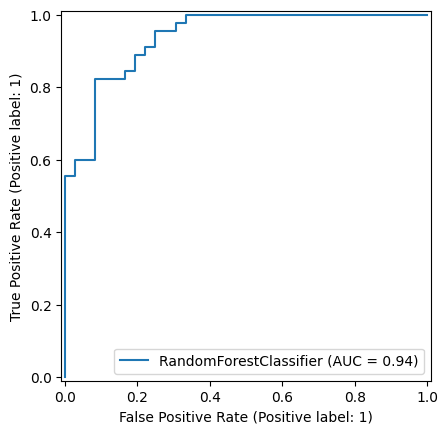

In [31]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.savefig("roc_curve.png", dpi=300)
plt.show()

In [32]:
df.to_excel("FABP5_clean_dataset.xlsx", index=False)

In [33]:
from google.colab import files

files.download("FABP5_clean_dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
import pandas as pd

cv_df = pd.DataFrame({
    "Fold": range(len(scores)),
    "ROC-AUC": scores
})

cv_df.to_excel(
    "cross_validation_results.xlsx",
    index=False
)

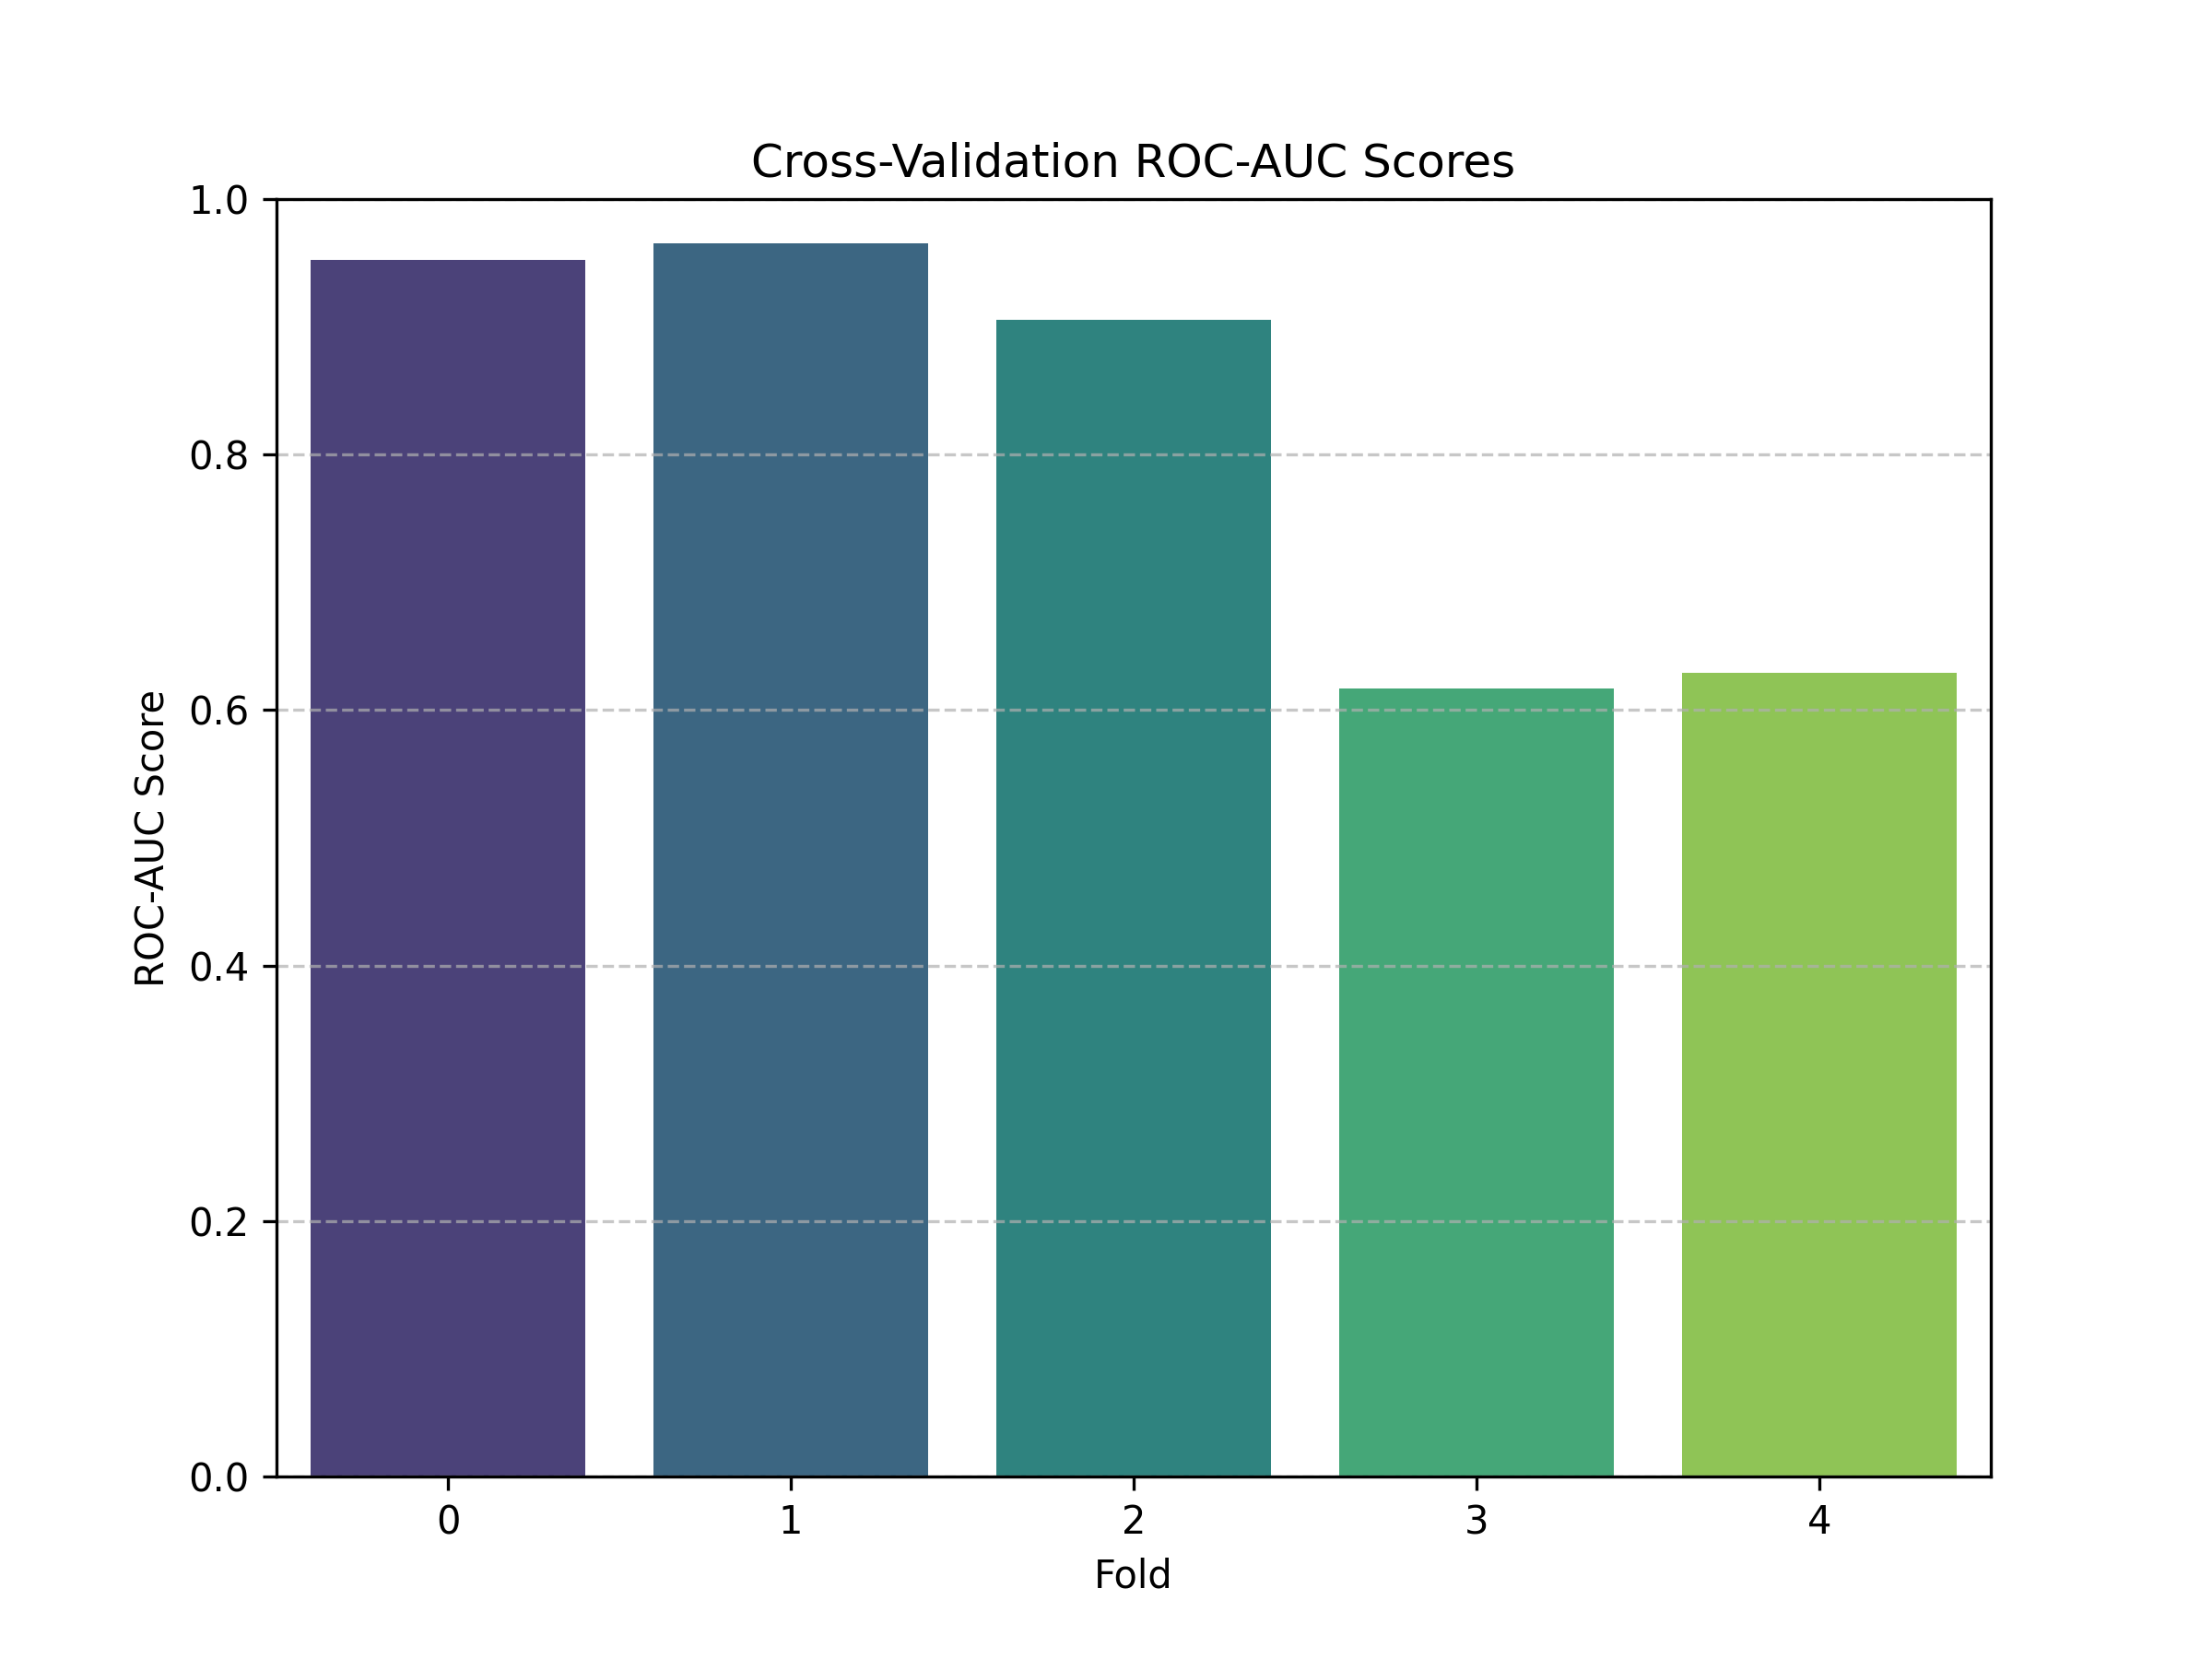

In [44]:
from IPython.display import Image
Image('roc_auc_bar_chart.png')

In [45]:
from google.colab import files
files.download('roc_auc_bar_chart.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
from google.colab import files

files.download("cross_validation_results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
from google.colab import files

files.download("cross_validation_results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
plt.savefig("roc_curve.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [46]:
from google.colab import files

files.download("roc_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>